# Weak OT Barycentric Projection

This notebook generates `fig:weak-ot-barycentric-projection`.  A small centered red disk source is coupled to a blue annulus target with three times more target atoms.  The left panel shows conditional splitting, while the right panel collapses each conditional law to its barycenter
$$
    \bar y(x)=\int y\,d\pi_x(y).
$$
The disk and annulus use the same canonical semi-regular noisy samples as the basic matching figures, so the red disk stays centered and the blue target surrounds it.


In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate notebooks-figures/figure_style.py")

sys.path.insert(0, str(FIGROOT))

import matplotlib.pyplot as plt
import numpy as np

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    ORANGE,
    GRAY,
    LIGHT_GRAY,
    DIRAC_MARKER_SIZE,
    box_axes,
    draw_point_clouds,
    draw_transport_segments,
    canonical_matching_clouds,
    figure_dir,
    interp_color,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "weak-ot-barycentric-projection"
out = figure_dir(NAME)
rng = np.random.default_rng(284)

In [2]:
x, y, labels = canonical_matching_clouds(seed=284, n_source=18, target_counts=(18, 18, 18))
source_center = np.zeros(2)
target_center = np.zeros(2)

P = np.zeros((len(x), len(y)))
for i, xi in enumerate(x):
    direction = xi - source_center
    direction = direction / max(np.linalg.norm(direction), 1e-12)
    preferred = target_center + 0.94 * direction
    d2 = np.sum((y - preferred) ** 2, axis=1)
    idx = np.argsort(d2)[:7]
    w = np.exp(-d2[idx] / 0.030)
    w = w / w.sum()
    P[i, idx] = w / len(x)
# Give every target atom a tiny visible mass so the annulus support is readable.
P = 0.985 * P + 0.015 * np.ones_like(P) / P.size
a = P.sum(axis=1)
b = P.sum(axis=0)
bar = (P @ y) / a[:, None]
pairs = [(i, j, float(P[i, j])) for i in range(P.shape[0]) for j in range(P.shape[1]) if P[i, j] > 1.8e-4]
all_points = np.vstack([x, y, bar])
xlim, ylim = padded_limits(all_points, pad=0.09)


In [3]:
def decorate(ax):
    ax.set_aspect("equal")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    remove_axes(ax)

fig, ax = plt.subplots(figsize=(2.45, 2.05))
draw_transport_segments(ax, x, y, pairs, color=VIOLET, min_width=0.09, max_width=0.98, alpha_scale=0.42, zorder=1)
draw_point_clouds(ax, x, y, source_weights=a, target_weights=b, base_size=DIRAC_MARKER_SIZE * 0.58)
decorate(ax)
save_pdf(fig, out / "conditional-coupling.pdf", pad_inches=0.035)
plt.close(fig)

fig, ax = plt.subplots(figsize=(2.45, 2.05))
draw_transport_segments(ax, x, y, pairs, color=LIGHT_GRAY, min_width=0.08, max_width=0.55, alpha_scale=0.18, zorder=1)
for i in range(len(x)):
    ax.plot([x[i, 0], bar[i, 0]], [x[i, 1], bar[i, 1]], color=VIOLET, lw=0.88, alpha=0.86, zorder=2)
ax.scatter(bar[:, 0], bar[:, 1], s=DIRAC_MARKER_SIZE * 0.50, marker="o", color=VIOLET, edgecolor="none", linewidth=0, zorder=4)
draw_point_clouds(ax, x, y, source_weights=a, target_weights=b, base_size=DIRAC_MARKER_SIZE * 0.58)
decorate(ax)
save_pdf(fig, out / "barycentric-projection.pdf", pad_inches=0.035)
plt.close(fig)

## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


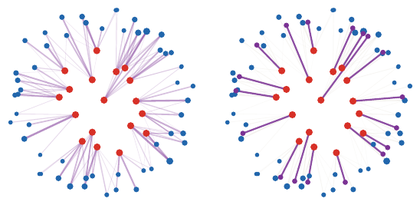

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/weak-ot-barycentric-projection.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/weak-ot-barycentric-projection.png")
display(Image(filename=str(_thumb)))
